# Project Python Foundations: FoodHub Data Analysis

**Marks: 60**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('/content/drive/My Drive/Python/foodhub_order.csv')
# or use this; df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
df.shape # this returns (number of rows, number of columns)

(1898, 9)

#### Observations:
1. There are  1898 rows and 9 columns
2. The amount of rows and columns represents 1,898 orders and 9 relevant variables covering operational, customer, and performance metrics


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
# Use info() to print a concise summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
1. The data set contains 4 integer columns, 1 float column, and 4 object/string columns
2. The ratings column is stored as an object/string instead of numerical. This might need to be cleaned up to be all numerical to calculate averages and understanding customer satisfaction trends.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
df.isnull().sum() # this checks for the missing values and counts them column wise

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


#### Observations:
1. There are no explicit missing missing values in the dataset
2.  Although no values are technically missing, the rating column contains “not given”, which represents implicit missing feedback. From a business perspective, this indicates that not all customers provide ratings


### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000


In [ ]:
print("Minimum preparation time:", df['food_preparation_time'].min())
print("Average preparation time:", df['food_preparation_time'].mean())
print("Maximum preparation time:", df['food_preparation_time'].max())

Minimum preparation time: 20
Average preparation time: 27.371970495258168
Maximum preparation time: 35


#### Observations:
1. The average food preperation time is approximately 27 minutes indicating that customers typically wait nearly half an hour before delivery begins.
2. The range of 20-35 minutes shows consistency in prep times across restaurants.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
(df['rating'] == 'Not given').sum() # this filters the rows where ratings is 'Not given' and sums them

np.int64(736)

#### Observations:
1. 736 out of 1,898 orders were not rated
2. The high number of unrated orders might impact the reliability of the customer satisfaction analysis

### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

In [ ]:
# do ALL variables even if we cant show a visual for it, we still need to state
# an observation/analysis

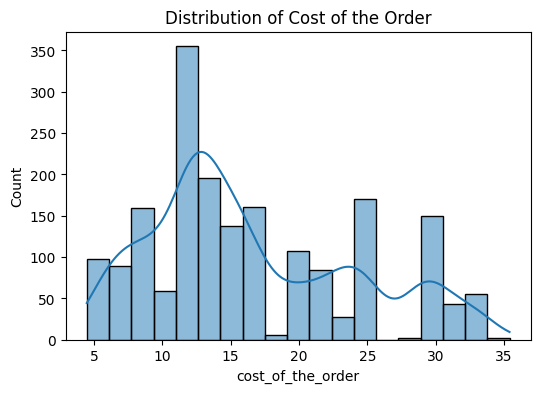

In [ ]:
# I am going to analyze each variables individually
# first numerical, categorical, visualizations, and observations

# Numerical Variables
# --> cost of the order
plt.figure(figsize=(6,4))
sns.histplot(df['cost_of_the_order'], kde=True)
plt.title("Distribution of Cost of the Order")
plt.show()

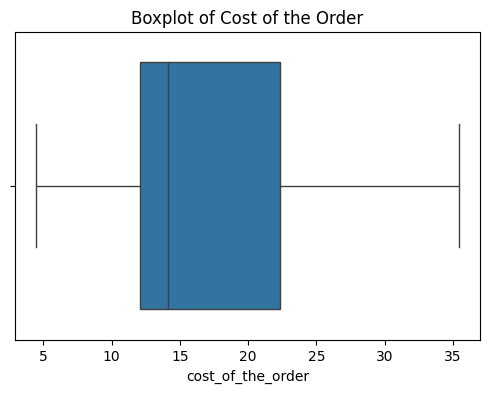

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['cost_of_the_order'])
plt.title("Boxplot of Cost of the Order")
plt.show()

#### Observations:
1. The distribution of order costs are slightly right skewed showing that customers place moderatelly priced orders with fewer higher purchases

In [ ]:
# --> order id
df['order_id'].nunique()

1898

#### Observations:
1. All order ID's are unique confirming there are no duplicates in the dataset

In [ ]:
# --> customer id
df['customer_id'].nunique()

1200

#### Observations:
1. There are 1,200 unique customers buyt 1,898 total orders indicating customers have placed more than one order

In [ ]:
# --> restaurant name
df['restaurant_name'].value_counts()

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68
...,...
Rye House,1
Hiroko's Place,1
Frank Restaurant,1


#### Observations:
1. Demand is highly concentrated among a few restaurants. Shake Shack alone received 219 orders, significantly higher than most other restaurants.
2. There are 178 restaurants listed, but many have very low order counts.

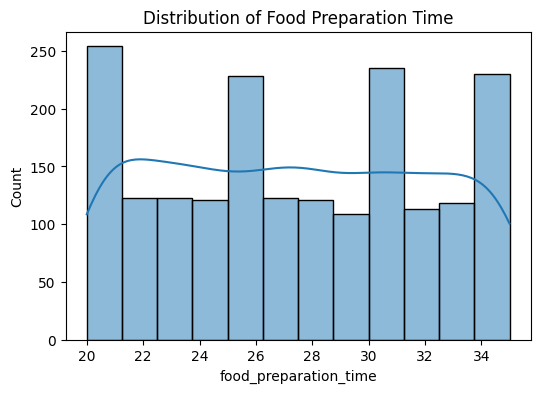

In [ ]:
# --> food preperation time
plt.figure(figsize=(6,4))
sns.histplot(df['food_preparation_time'], kde=True)
plt.title("Distribution of Food Preparation Time")
plt.show()

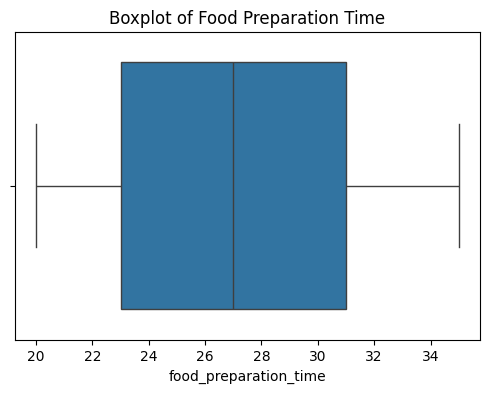

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['food_preparation_time'])
plt.title("Boxplot of Food Preparation Time")
plt.show()

#### Observations:
1. Food prep is pretty consistent indicating that restaurant operations are stable

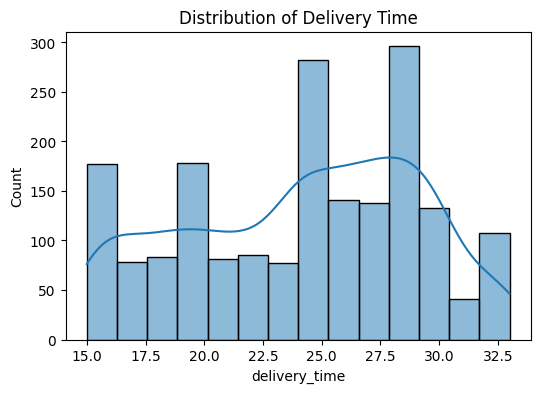

In [ ]:
# --> delivery time
plt.figure(figsize=(6,4))
sns.histplot(df['delivery_time'], kde=True)
plt.title("Distribution of Delivery Time")
plt.show()

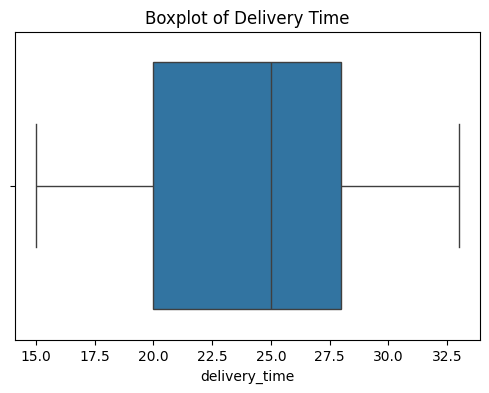

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['delivery_time'])
plt.title("Boxplot of Delivery Time")
plt.show()

#### Observations:
1. Delivery times show wide variation indicating delivery logistics may experience fluctuations due to traffic, distance, or demand.

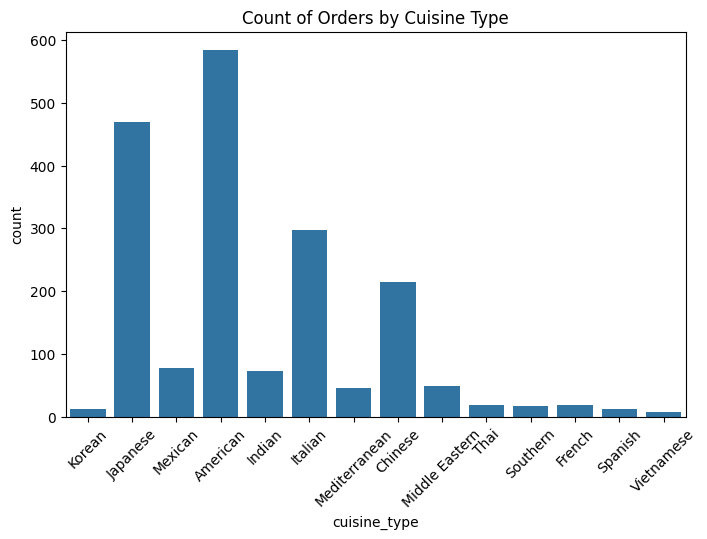

In [ ]:
# Categorical Variables
# --> cuisine type
plt.figure(figsize=(8,5))
sns.countplot(x='cuisine_type', data=df)
plt.xticks(rotation=45)
plt.title("Count of Orders by Cuisine Type")
plt.show()

#### Observations:
1. Certain cuisines dominate which indicate customers have clear preferences.
2. Japanese, American, Italian, and Chinese are preffered more than the rest with American at the highest.

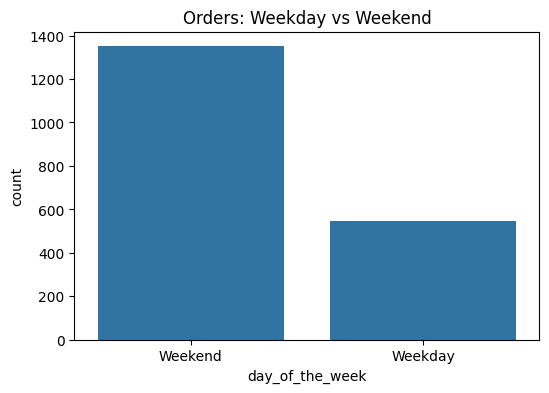

In [ ]:
# --> day of the week
plt.figure(figsize=(6,4))
sns.countplot(x='day_of_the_week', data=df)
plt.title("Orders: Weekday vs Weekend")
plt.show()

#### Observations:
1. Customers seem to rely more heavily on food delivery during weekends.

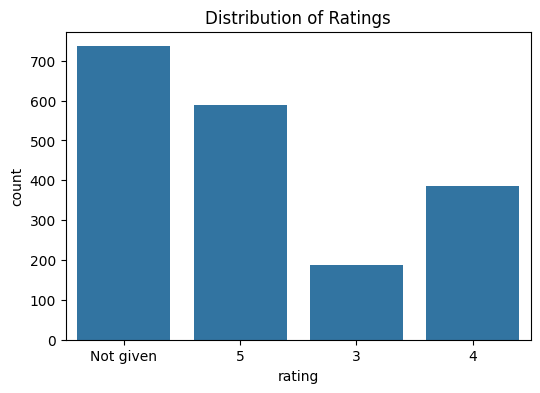

In [ ]:
# --> ratings
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title("Distribution of Ratings")
plt.show()

#### Observations:
1. Most given ratings appear concentrated around higher values (4 and 5), suggesting positive customer satisfaction. However, a significant portion of orders are left unrated which limits full satisfaction assessment.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
top5_rest = df['restaurant_name'].value_counts().head(5)
top5_rest
# this gives me the count of how many times each restaurant appears and then the top 5 of that

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
1. Shake Shack clearly dominates order volume with 219 orders which is quite a bit higher than the other restaurants indicating strong preferance.
2. There is a noticeable drop in order count after the top restaurant which suggests demand is concentrated among a few key restaurants.


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
df['day_of_the_week'].unique()

array(['Weekend', 'Weekday'], dtype=object)

In [ ]:
weekend_data = df[df['day_of_the_week'] == 'Weekend']
weekend_data['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


In [ ]:
weekend_data['cuisine_type'].value_counts().head(1)

,count
cuisine_type,
American,415


#### Observations:
1. The most popular cuisine on weekends is American.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
orders_above20 = df[df['cost_of_the_order'] > 20].shape[0]
orders_above20

555

In [ ]:
percentage = (orders_above20 / df.shape[0]) * 100
percentage

29.24130663856691

#### Observations:
1. Approximately 29.2% of the orders cost more than $20.


### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
df['delivery_time'].mean()

np.float64(24.161749209694417)

#### Observations:
1. On average, customers wait approximately 24 minutes for delivery after food prep is completed.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 5 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
top5_customers = df['customer_id'].value_counts().head(5)
top5_customers

,count
customer_id,
52832,13
47440,10
83287,9
250494,8
259341,7


#### Observations:
The top 5 most frequent customers and their number of orders are:


*   Customer ID 52832 --> 13 orders
*   Customer ID 47440 --> 10 orders
*   Customer ID 83287 --> 9 orders
*   Customer ID 250494 --> 8 orders
* Customer ID 259341 --> 7 orders

### Bivariate and Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


In [ ]:
# cleaning up the rating variables
df['rating'] = df['rating'].replace('Not given', np.nan)
df['rating'] = pd.to_numeric(df['rating'])

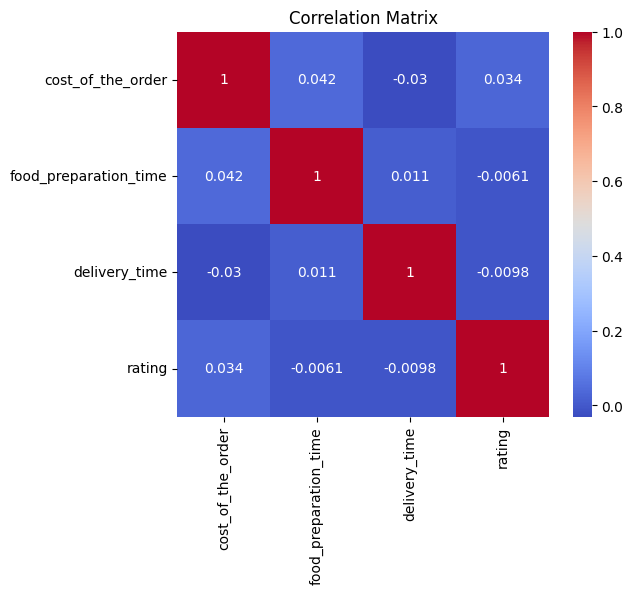

In [ ]:
# Numerical vs Numerical
# heatmap for the variables to see if there are any correlations between them
plt.figure(figsize=(6,5))
sns.heatmap( df[['cost_of_the_order', 'food_preparation_time','delivery_time','rating']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

#### Observations:
1. All correlations among numeric variables are near zero indicating no strong linear relationships.
2.	Order cost is essentially independent of preparation time, delivery time, and customer rating, implying spending level is not a major driver of operational performance or satisfaction.
3.	Delivery time and preparation time are not correlated suggesting delivery delays are likely driven by logistics rather than restaurant preparation efficiency.

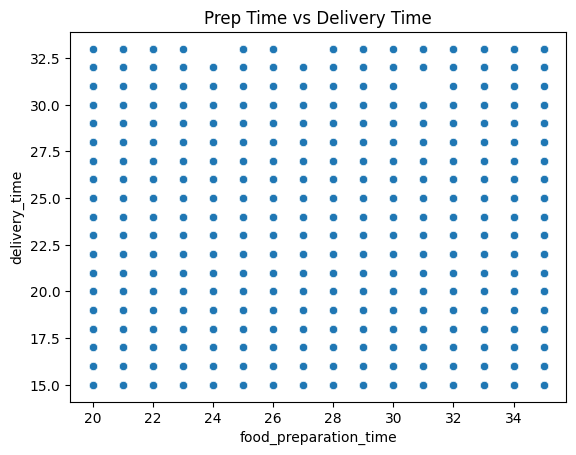

In [ ]:
# prep time vs delivery time
sns.scatterplot( x='food_preparation_time',y='delivery_time',data=df)
plt.title("Prep Time vs Delivery Time")
plt.show()

#### Observations:
The scatter plot of food preparation time vs delivery time does not seem to reveal any clear linear trend. The points are evenly distributed across combinations of integer values, suggesting no meaningful relationship between restaurant prep time and delivery duration. This indicates that delivery efficiency may be driven more by other factors rather than restaurant preparation speed.


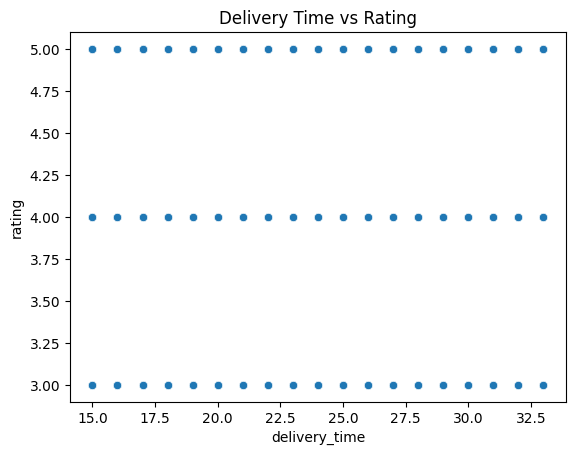

In [ ]:
# Delivery time vs rating
sns.scatterplot(x='delivery_time',y='rating',data=df)
plt.title("Delivery Time vs Rating")
plt.show()

#### Observations:
The scatter plot of delivery time versus rating shows no clear linear relationship. Ratings (3, 4, and 5) are distributed across all delivery times, indicating that variations in delivery time do not strongly influence customer satisfaction. The correlation coefficient (r ≈ -0.01) further confirms the absence of a meaningful linear association.

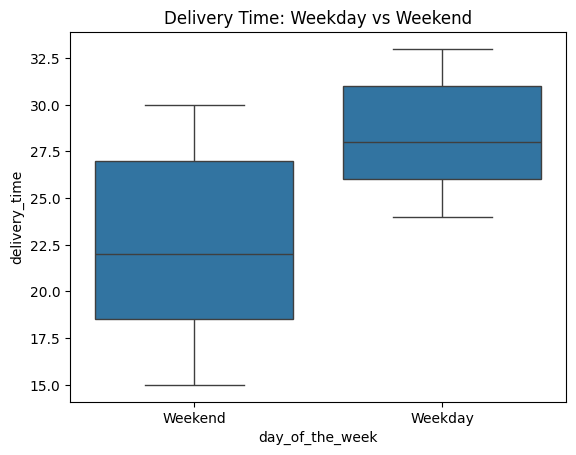

In [ ]:
# Numerical vs Categorical
# delivery time by day type
sns.boxplot(x='day_of_the_week',y='delivery_time',data=df)
plt.title("Delivery Time: Weekday vs Weekend")
plt.show()

#### Observations:
The boxplot indicates that delivery times are generally longer on weekdays compared to weekends. The median weekday delivery time (approximately 28 minutes) exceeds the weekend median (approximately 22 minutes), suggesting that traffic congestion or weekday demand patterns may slow down deliveries.

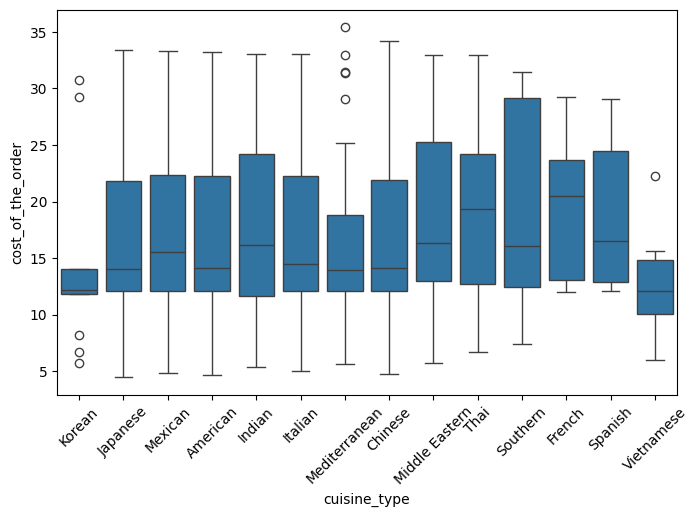

In [ ]:
# cost by cuisine type
plt.figure(figsize=(8,5))
sns.boxplot(x='cuisine_type',y='cost_of_the_order',data=df)
plt.xticks(rotation=45)
plt.show()

#### Observations:
Order value varies greatly across cuisines indicating that certain cuisine types generate higher revenue per transaction. Specifically Thai, French, and Spanish cuisines exhibit higher median order costs. Lower-cost cuisines such as Korean and Vietnamese may drive order frequency rather than high revenue per order. The presence of outliers in some cuisines indicates occasional large purchases that contribute disproportionately to total revenue.

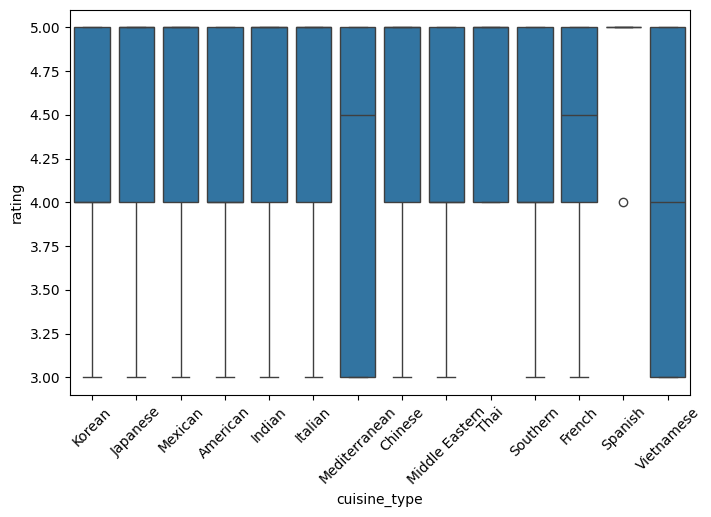

In [ ]:
# rating by cuisine
plt.figure(figsize=(8,5))
sns.boxplot(x='cuisine_type',y='rating',data=df)
plt.xticks(rotation=45)
plt.show()

#### Observations:
Ratings are consistently high (mostly 4 and 5) across all cuisine types, indicating strong overall customer satisfaction. There is minimal variation in median ratings between cuisines, suggesting cuisine type is not a primary determinant of customer satisfaction.

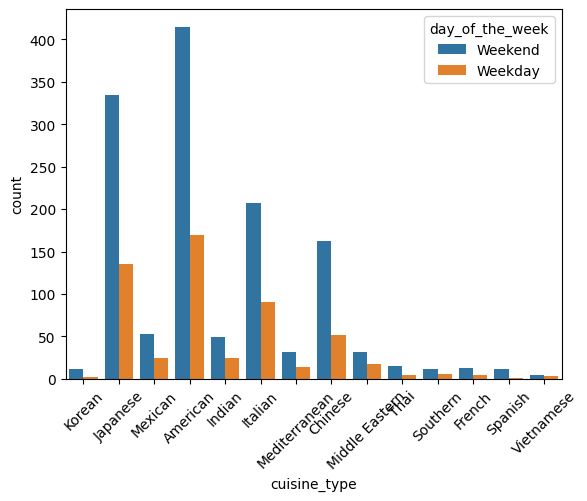

In [ ]:
# Categorical vs Categorical
# cuisine by day of the week
sns.countplot(x='cuisine_type',hue='day_of_the_week',data=df)
plt.xticks(rotation=45)
plt.show()

#### Observations:
Order volume is significantly higher on weekends across nearly all cuisine types, indicating that FoodHub experiences peak demand during non working days. American cuisine remains consistently popular across weekdays and weekends, making it a core category for sustained revenue.

In [ ]:
df.groupby('cuisine_type')[['cost_of_the_order','delivery_time','rating']].mean()

,cost_of_the_order,delivery_time,rating
cuisine_type,,,
American,16.319829,24.193493,4.298913
Chinese,16.305209,23.855814,4.338346
French,19.793889,25.333333,4.300000
Indian,16.919726,24.082192,4.540000
Italian,16.418691,24.567114,4.360465
Japanese,16.304532,24.131915,4.373626
Korean,14.001538,20.923077,4.111111
Mediterranean,15.474783,23.586957,4.218750
Mexican,16.933117,24.389610,4.416667


#### Observations:
Cuisines such as French, Southern, Thai, and Spanish generate the highest average order values, contributing more revenue per transaction.
Spanish and Thai cuisines exhibit both high average order value and high customer ratings, indicating strong performance in both profit and satisfaction.
Vietnamese cuisine shows the lowest average cost, longest delivery time, and lowest rating, suggesting potential operational or quality issues.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# making sure ratings are numeric again (just in case)
df['rating'] = df['rating'].replace('Not given', np.nan)
df['rating'] = pd.to_numeric(df['rating'])

In [ ]:
# then getting the count of ratings and the average rating
restaurant_ratings = (df.groupby('restaurant_name')['rating'].agg(['count', 'mean']))

In [ ]:
# then applying the conditions (rating count > 50 and average rating >4)
# so then the result should be restaurants with at least 51 ratings and maintain high rating/satisfaction
promo_restaurants = restaurant_ratings[
    (restaurant_ratings['count'] > 50) &
    (restaurant_ratings['mean'] > 4)]
promo_restaurants

,count,mean
restaurant_name,,
Blue Ribbon Fried Chicken,64,4.328125
Blue Ribbon Sushi,73,4.219178
Shake Shack,133,4.278195
The Meatball Shop,84,4.511905


#### Observations:
1. Only four restaurants satisfy both the popularity condition (more than 50 ratings) and the quality condition (average rating above 4).
This suggests that high volume feedback and high satisfaction is not as common.
2. Shake Shack has the highest rating count (133), making it the most “proven” restaurant in terms of customer feedback volume.
3. The Meatball Shop has the highest average rating (approximately 4.51) among the restaurants.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
# the conditions are if cost > 20 then commission is 25%
# and if 5 < cost <= 20 then commission is 15%
# and if cost <= 5 then commission is 0%
df['commission'] = np.where(
    df['cost_of_the_order'] > 20,
    df['cost_of_the_order'] * 0.25,
    np.where(
        df['cost_of_the_order'] > 5,
        df['cost_of_the_order'] * 0.15,
        0))

In [ ]:
# then calculating total revenue
total_revenue = df['commission'].sum()
total_revenue

np.float64(6166.303)

In [ ]:
print(f"Total net revenue generated by the company: ${total_revenue:.2f}")

Total net revenue generated by the company: $6166.30


#### Observations:
1. The company generates $6,166.30 in commission revenue from 1,898 orders.

2. Since higher cost orders are charged at 25%, these orders likely contribute disproportionately to total revenue despite being fewer in number


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# creating the total time column
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

In [ ]:
# counting the orders that take more than 60 minutes long
orders_above_60 = df[df['total_time'] > 60].shape[0]
orders_above_60

200

In [ ]:
percentage_above_60 = (orders_above_60 / df.shape[0]) * 100
print(f"Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%")

Percentage of orders taking more than 60 minutes: 10.54%


#### Observations:
1. Approximately one in ten orders exceeds 60 minutes total delivery time.
This might impact customer satisfaction.

2. Although the majority of orders are delivered within an hour, a 10.54% delay rate suggests room for improvement.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [ ]:
# calculating the mean delivery time by day (weekday or weekend)
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


#### Observations:
1. Delivery times are significantly higher on weekdays (28.34 minutes) compared to weekends (22.47 minutes).
This suggests there must be certain factors internally or externally affecting delivery time.

2. Theres about a 6 minute difference representing a substantial change in customer waiting time.

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  Order demand is heavily concentrated among a few restaurants and cuisines. A small number of restaurants (like Shake Shack and a few others) receive a much larger share of total orders. Similarly, American cuisine dominates overall demand. This shows that customer preferences are not evenly distributed. FoodHub seems to rely strongly on certain high performing restaurants and cuisines to drive overall activity and revenue.

* Weekday delivery performance is noticeably slower than weekend performance. The mean delivery time on weekdays (28.34 minutes) is almost 6 minutes longer than weekends (22.47 minutes). That is a meaningful difference and suggests that weekday factors like traffic or higher congestion may be affecting operations. Even though weekend demand is high, delivery seems more efficient during that time.

* Some cuisines generate higher revenue per order than others.
Cuisines such as French, Thai, Southern, and Spanish have higher average order costs, meaning they bring in more commission per transaction. On the other hand, cuisines like Vietnamese and Korean have lower average order values. This shows that not all cuisines contribute equally to total revenue.

* Customer ratings are generally strong, but not strongly tied to delivery time or cost. Most cuisines have average ratings above 4, which is a positive sign for overall service quality. However, ratings did not show strong correlations with delivery time or cost, meaning customer satisfaction may depend on other factors like food quality or restaurant consistency rather than just speed or price.

* About 10.54% of orders take more than 60 minutes from placement to delivery. While most orders are completed within an hour, roughly 1 in 10 customers waits longer than 60 minutes. That is not insignificant and could impact repeat purchases or long term satisfaction if not addressed.

### Recommendations:

* Focus on improving weekday delivery efficiency. Since weekday delivery times are longer, FoodHub should look into optimizing driver allocation, route planning, and peak hour coverage during weekdays. Even reducing delivery time by a few minutes could meaningfully improve the overall customer experience and potentially increase repeat usage.

* Promote high performing, high revenue cuisines. Cuisines like Spanish and Thai not only have higher average order values but also strong ratings. These are ideal candidates for featured promotions or advertisements because they combine profitability with customer satisfaction. Highlighting these cuisines could increase both revenue and engagement.

* Support improvement in lower performing cuisines. For example
Vietnamese cuisine shows lower average cost, longer delivery times, and slightly lower ratings. This might indicate operational or service inconsistencies. FoodHub could analyze restaurant level data within that category to identify specific improvement opportunities.

* Encourage more customer ratings.
A large number of orders were not rated, which limits the company's ability to fully assess customer satisfaction. Possibly offering small incentives or reminders to leave feedback could improve the data and help FoodHub better monitor service performance.

* Target high frequency customers with loyalty incentives. The top customers placed multiple orders, showing a strong repeat behavior. Providing loyalty rewards or personalized promotions to these users could increase customer lifetime value and strengthen long term retention.

---